In [1]:
# Cell 1 - Import Libraries
# وارد کردن کتابخانه ها

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Cell 2 - Load Data
# بارگذاری داده ها

from pathlib import Path

csv_files = list(Path('.').glob('*.csv'))
if csv_files:
    df = pd.read_csv(csv_files[0])
else:
    raise FileNotFoundError('CSV file not found. Please place the dataset next to the notebook.')

print('Rows    (تعداد رکورد):', df.shape[0])
print('Columns (تعداد ستون):', df.shape[1])
df.head()


Rows    (تعداد رکورد): 418
Columns (تعداد ستون): 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# Cell 3 - Data Structure
# بررسی ساختار داده ها

print('--- Data Types ---')
print(df.dtypes)
print()

# توضیح ستون ها
# PassengerId : کمی گسسته  - شناسه مسافر
# Survived    : کیفی دوتایی - 0=فوت  1=نجات
# Pclass      : کیفی ترتیبی - کلاس بلیت 1،2،3
# Name        : کیفی اسمی  - نام مسافر
# Sex         : کیفی اسمی  - جنسیت
# Age         : کمی پیوسته - سن
# SibSp       : کمی گسسته  - تعداد خواهر/برادر یا همسر
# Parch       : کمی گسسته  - تعداد والدین یا فرزند
# Fare        : کمی پیوسته - قیمت بلیت
# Cabin       : کیفی اسمی  - شماره کابین
# Embarked    : کیفی اسمی  - بندر سوار شدن

print('--- Descriptive Statistics ---')
df[['Age', 'Fare', 'SibSp', 'Parch']].describe().round(2)

--- Data Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

--- Descriptive Statistics ---


,Age,Fare,SibSp,Parch
count,332.00,417.00,418.00,418.00
mean,30.27,35.63,0.45,0.39
std,14.18,55.91,0.90,0.98
min,0.17,0.00,0.00,0.00
25%,21.00,7.90,0.00,0.00
50%,27.00,14.45,0.00,0.00
75%,39.00,31.50,1.00,0.00
max,76.00,512.33,8.00,9.00


In [4]:
# Cell 4 - Categorical Columns
# توزیع ستون های کیفی

for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- Survived ---
Survived
0    266
1    152
Name: count, dtype: int64

--- Pclass ---
Pclass
3    218
1    107
2     93
Name: count, dtype: int64

--- Sex ---
Sex
male      266
female    152
Name: count, dtype: int64

--- Embarked ---
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64



       Count  Percent%
Age       86      20.6
Fare       1       0.2
Cabin    327      78.2


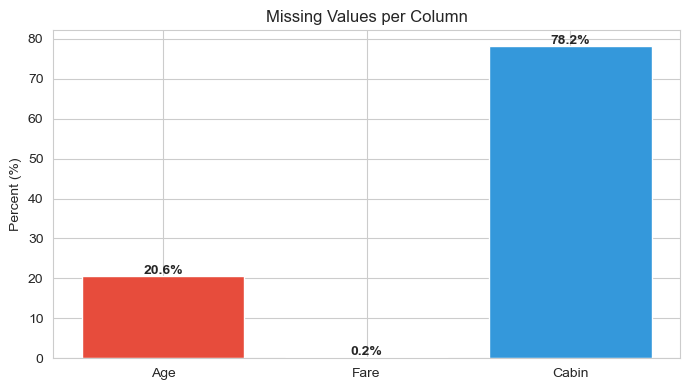

In [5]:
# Cell 5 - Missing Values
# بررسی مقادیر گمشده

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
result = pd.DataFrame({'Count': missing, 'Percent%': missing_pct})
result = result[result['Count'] > 0]
print(result)

# نمودار مقادیر گمشده
plt.figure(figsize=(7, 4))
plt.bar(result.index, result['Percent%'], color=['#e74c3c','#e67e22','#3498db'])
plt.title('Missing Values per Column')
plt.ylabel('Percent (%)')
for i, v in enumerate(result['Percent%']):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

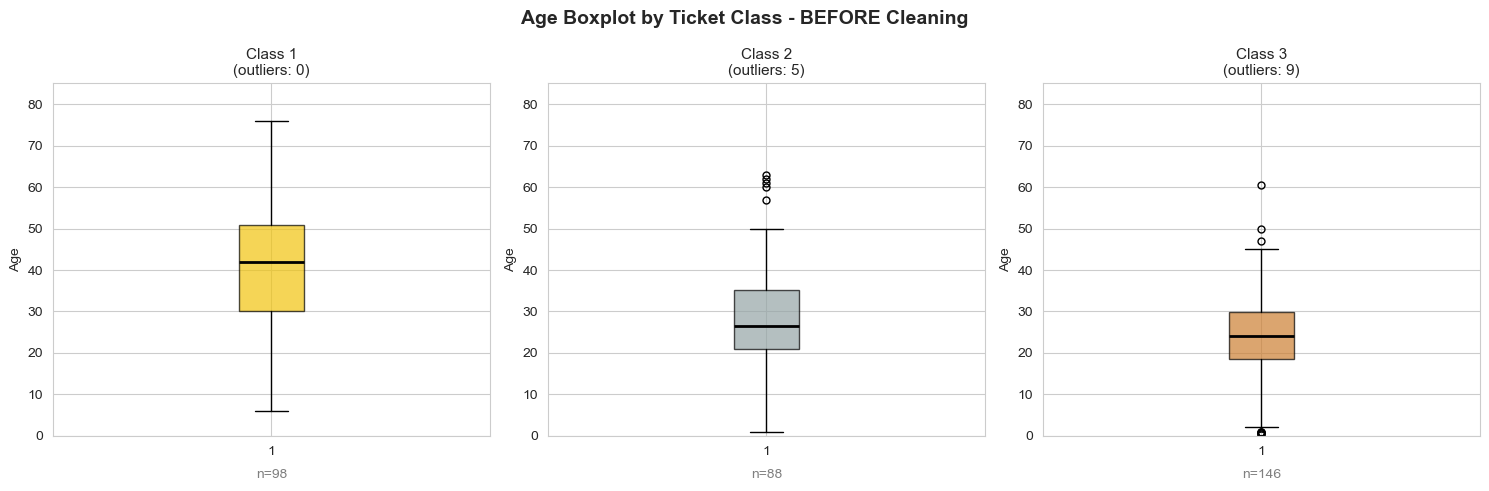

In [6]:
# Cell 6 - Boxplot BEFORE Cleaning (Age by Pclass 1,2,3)
# نمودار جعبه ای قبل از پاکسازی - کلاس‌های 1 تا 3

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Age Boxplot by Ticket Class - BEFORE Cleaning', fontsize=14, fontweight='bold')

colors = ['#f1c40f', '#95a5a6', '#cd7f32']
class_labels = ['Class 1', 'Class 2', 'Class 3']

for ax, pclass, color, label in zip(axes, [1, 2, 3], colors, class_labels):
    data = df[df['Pclass'] == pclass]['Age'].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color='red', markersize=5))
    ax.set_title(f'{label}\n(outliers: {n_out})', fontsize=11)
    ax.set_ylabel('Age')
    ax.set_ylim(0, 85)   # محور Y یکسان برای مقایسه منصفانه
    ax.text(0.5, -0.12, f'n={len(data)}', transform=ax.transAxes,
            ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()


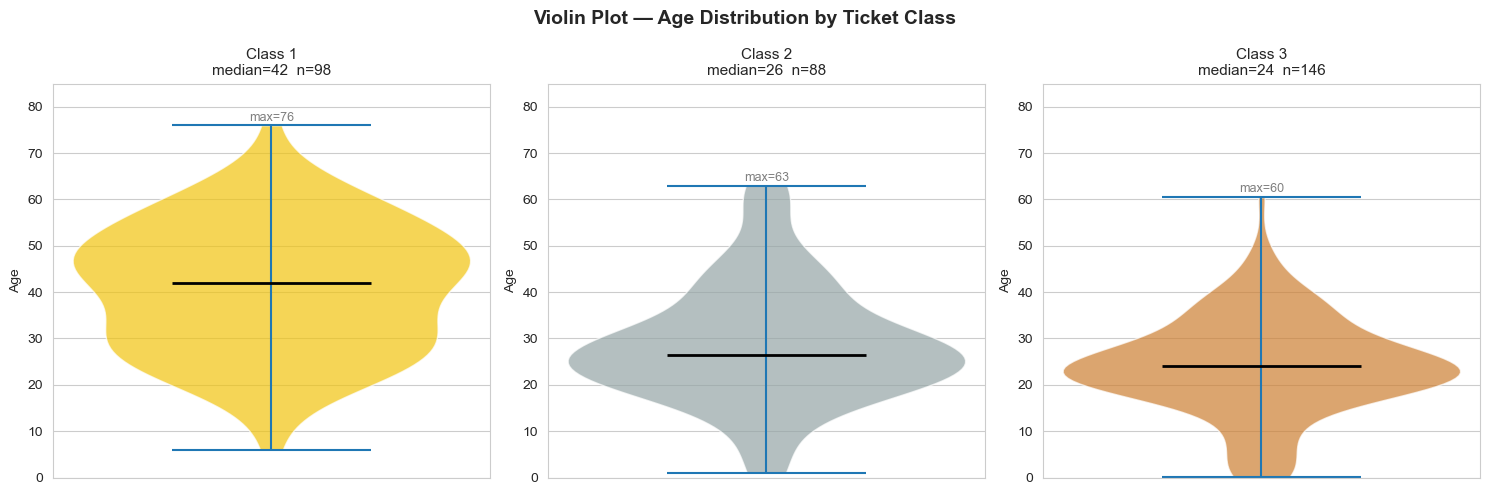

In [7]:
# Cell 7 - Violin Plot: Age Distribution by Pclass
# نمودار ویولن - توزیع سن به تفکیک کلاس بلیت

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Violin Plot — Age Distribution by Ticket Class', fontsize=14, fontweight='bold')

colors = ['#f1c40f', '#95a5a6', '#cd7f32']
class_labels = ['Class 1', 'Class 2', 'Class 3']

for ax, pclass, color, label in zip(axes, [1, 2, 3], colors, class_labels):
    data = df[df['Pclass'] == pclass]['Age'].dropna()
    parts = ax.violinplot(data, positions=[1], showmedians=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_title(f'{label}\nmedian={data.median():.0f}  n={len(data)}', fontsize=11)
    ax.set_ylabel('Age')
    ax.set_ylim(0, 85)   # محور Y یکسان برای مقایسه منصفانه
    ax.set_xticks([])
    ax.text(1, data.max() + 1, f'max={data.max():.0f}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


In [8]:
# Cell 8 - Outlier Analysis (IQR Method)
# تحلیل داده های پرت با روش IQR

print('Outlier Analysis using IQR Method')
print('Formula: Lower = Q1 - 1.5*IQR  |  Upper = Q3 + 1.5*IQR')
print('-' * 55)

for col in ['Age', 'Fare', 'SibSp']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    print(f'\n{col}:')
    print(f'  Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')
    print(f'  Lower={lower:.1f}  Upper={upper:.1f}')
    print(f'  Number of outliers: {len(outliers)}')

Outlier Analysis using IQR Method
Formula: Lower = Q1 - 1.5*IQR  |  Upper = Q3 + 1.5*IQR
-------------------------------------------------------

Age:
  Q1=21.0  Q3=39.0  IQR=18.0
  Lower=-6.0  Upper=66.0
  Number of outliers: 2

Fare:
  Q1=7.9  Q3=31.5  IQR=23.6
  Lower=-27.5  Upper=66.9
  Number of outliers: 55

SibSp:
  Q1=0.0  Q3=1.0  IQR=1.0
  Lower=-1.5  Upper=2.5
  Number of outliers: 11


In [9]:
# Cell 9 - Data Cleaning

df_clean = df.copy()

# Age
if 'Age' in df_clean.columns:
    df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked
if 'Embarked' in df_clean.columns:
    df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Fare
if 'Fare' in df_clean.columns:
    df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# Cabin
if 'Cabin' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Cabin'])

print('Data cleaning completed')
print(df_clean.shape)


Data cleaning completed
(418, 11)


تعداد مقادیر گمشده سن که در هر کلاس با median پر شدند:
  Class 1: 9 مقدار پر شد
  Class 2: 5 مقدار پر شد
  Class 3: 72 مقدار پر شد


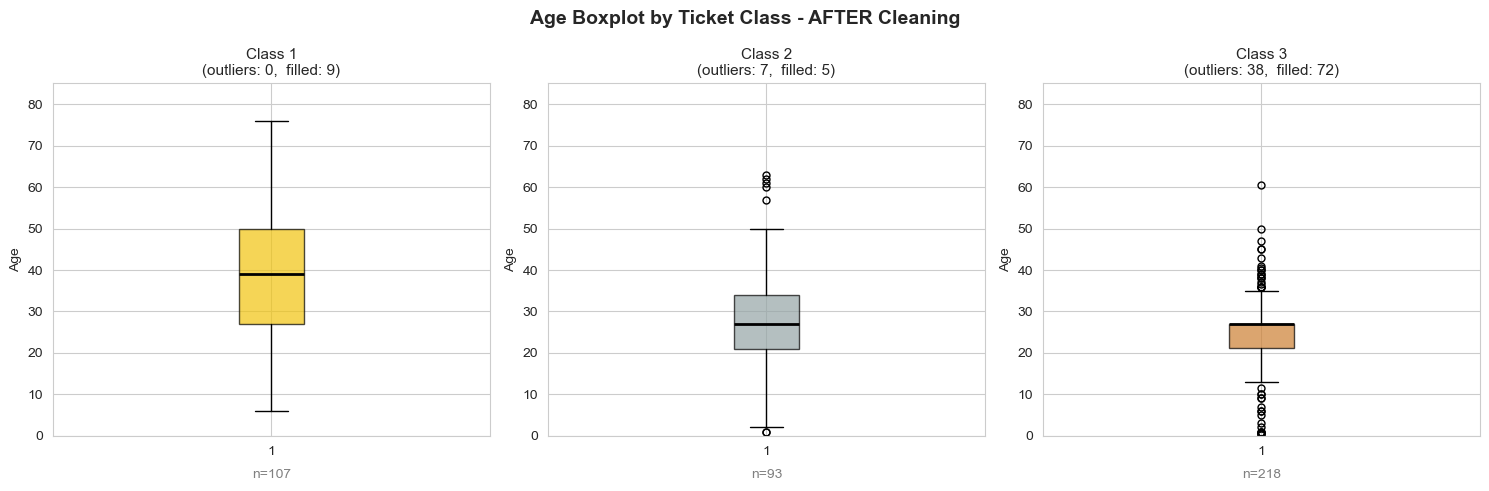

In [10]:
# Cell 10 - Boxplot AFTER Cleaning (Age by Pclass 1,2,3)
# نمودار جعبه ای بعد از پاکسازی - کلاس‌های 1 تا 3 + تعداد مقادیر پاکسازی‌شده

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Age Boxplot by Ticket Class - AFTER Cleaning', fontsize=14, fontweight='bold')

colors = ['#f1c40f', '#95a5a6', '#cd7f32']
class_labels = ['Class 1', 'Class 2', 'Class 3']

print('تعداد مقادیر گمشده سن که در هر کلاس با median پر شدند:')
for ax, pclass, color, label in zip(axes, [1, 2, 3], colors, class_labels):
    before_na = df[df['Pclass'] == pclass]['Age'].isna().sum()
    data = df_clean[df_clean['Pclass'] == pclass]['Age']
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    print(f'  {label}: {before_na} مقدار پر شد')
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color='red', markersize=5))
    ax.set_title(f'{label}\n(outliers: {n_out},  filled: {before_na})', fontsize=11)
    ax.set_ylabel('Age')
    ax.set_ylim(0, 85)   # محور Y یکسان برای مقایسه منصفانه
    ax.text(0.5, -0.12, f'n={len(data)}', transform=ax.transAxes,
            ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()


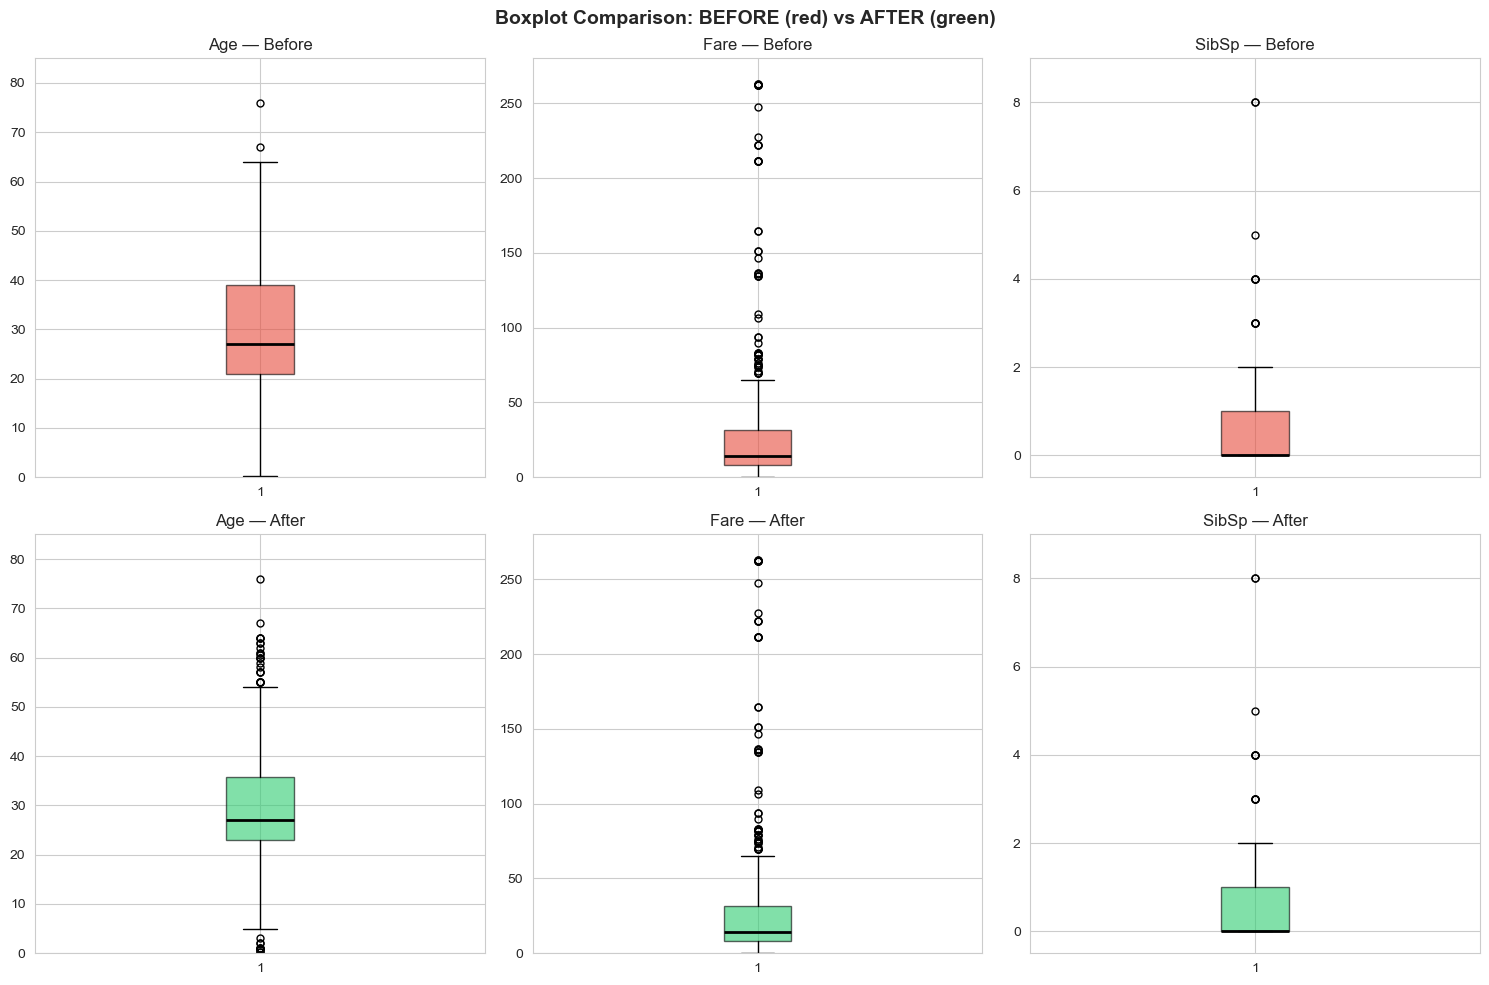

In [11]:
# Cell 11 - Boxplot AFTER Cleaning (Comparison)
# نمودار جعبه ای بعد از پاکسازی - مقایسه قبل و بعد

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplot Comparison: BEFORE (red) vs AFTER (green)', fontsize=14, fontweight='bold')

ylims = {'Age': (0, 85), 'Fare': (0, 280), 'SibSp': (-0.5, 9)}

for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    axes[0, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', color='darkred', markersize=5))
    axes[0, i].set_title(f'{col} — Before')
    axes[0, i].set_ylim(ylims[col])

    axes[1, i].boxplot(df_clean[col], patch_artist=True,
                       boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', color='darkgreen', markersize=5))
    axes[1, i].set_title(f'{col} — After')
    axes[1, i].set_ylim(ylims[col])

plt.tight_layout()
plt.show()


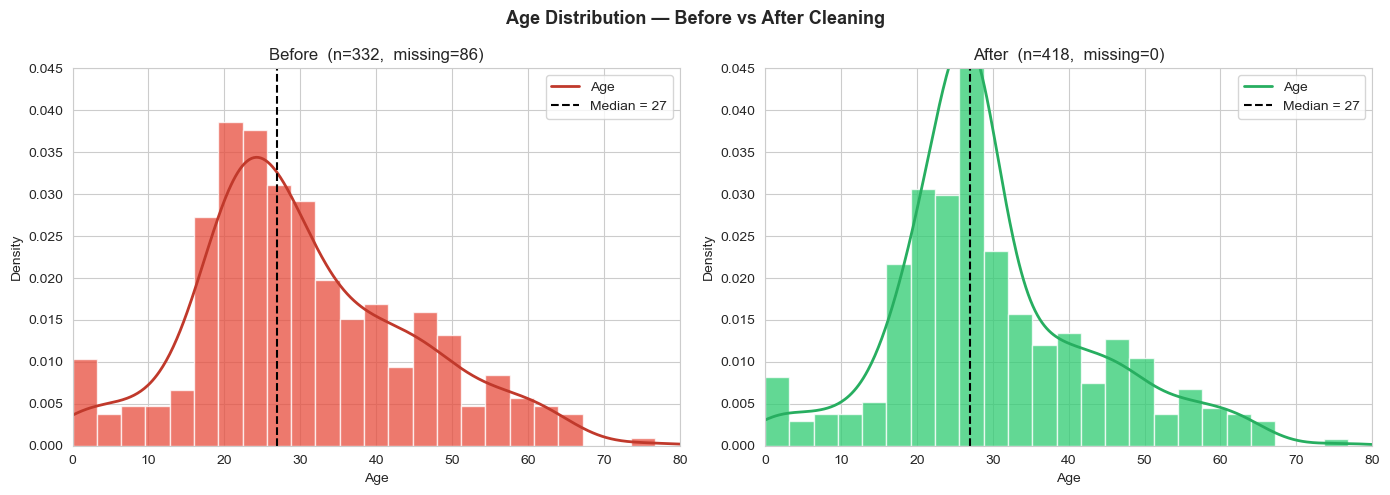

In [12]:
# Cell 12 - Age Distribution Before and After Cleaning
# توزیع سن قبل و بعد از پاکسازی

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution — Before vs After Cleaning', fontsize=13, fontweight='bold')

bins = np.linspace(0, 80, 26)

axes[0].hist(df['Age'].dropna(), bins=bins, color='#e74c3c', edgecolor='white', alpha=0.75, density=True)
df['Age'].dropna().plot.kde(ax=axes[0], color='#c0392b', linewidth=2)
axes[0].axvline(df['Age'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median = {df["Age"].median():.0f}')
axes[0].set_title(f'Before  (n={df["Age"].notna().sum()},  missing={df["Age"].isna().sum()})')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 80)
axes[0].set_ylim(0, 0.045)   # ylim یکسان
axes[0].legend()

axes[1].hist(df_clean['Age'], bins=bins, color='#2ecc71', edgecolor='white', alpha=0.75, density=True)
df_clean['Age'].plot.kde(ax=axes[1], color='#27ae60', linewidth=2)
axes[1].axvline(df_clean['Age'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median = {df_clean["Age"].median():.0f}')
axes[1].set_title(f'After  (n={len(df_clean)},  missing=0)')
axes[1].set_xlabel('Age')
axes[1].set_xlim(0, 80)
axes[1].set_ylim(0, 0.045)   # ylim یکسان
axes[1].legend()

plt.tight_layout()
plt.show()


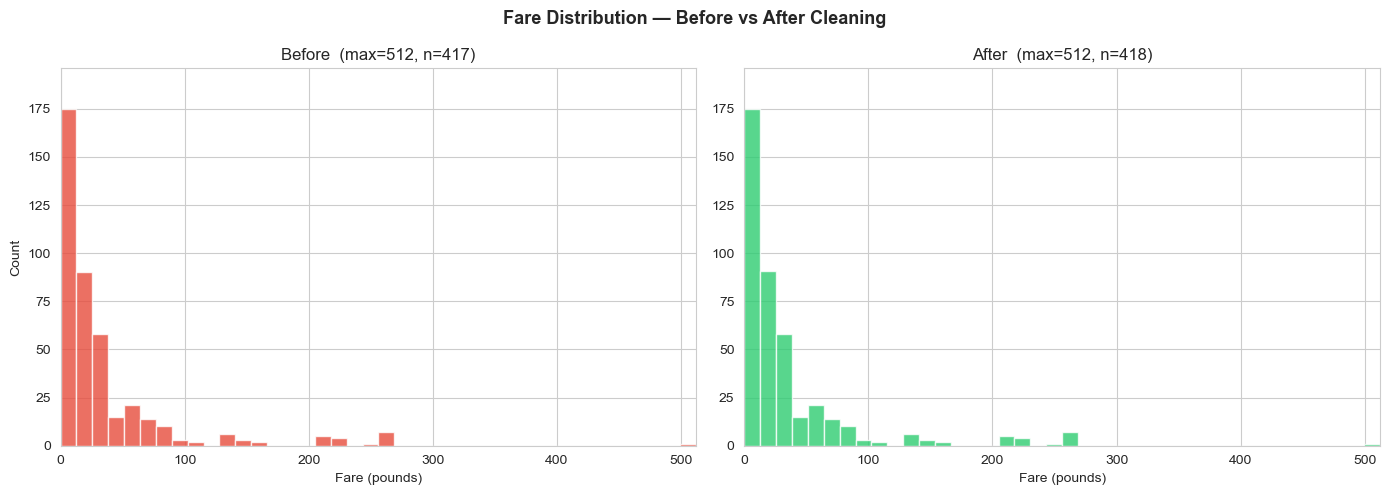

In [13]:
# Cell 13 - Fare Distribution Before and After
# توزیع قیمت بلیت قبل و بعد از پاکسازی

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fare Distribution — Before vs After Cleaning', fontsize=13, fontweight='bold')

max_fare = max(df['Fare'].max(), df_clean['Fare'].max())
bins = np.linspace(0, max_fare, 41)
max_count = max(
    np.histogram(df['Fare'].dropna(), bins=bins)[0].max(),
    np.histogram(df_clean['Fare'],    bins=bins)[0].max()
)

axes[0].hist(df['Fare'].dropna(), bins=bins, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Before  (max={df["Fare"].max():.0f}, n={df["Fare"].notna().sum()})')
axes[0].set_xlabel('Fare (pounds)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, max_fare)
axes[0].set_ylim(0, max_count * 1.12)   # ylim یکسان

axes[1].hist(df_clean['Fare'], bins=bins, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'After  (max={df_clean["Fare"].max():.0f}, n={len(df_clean)})')
axes[1].set_xlabel('Fare (pounds)')
axes[1].set_xlim(0, max_fare)
axes[1].set_ylim(0, max_count * 1.12)   # ylim یکسان

plt.tight_layout()
plt.show()


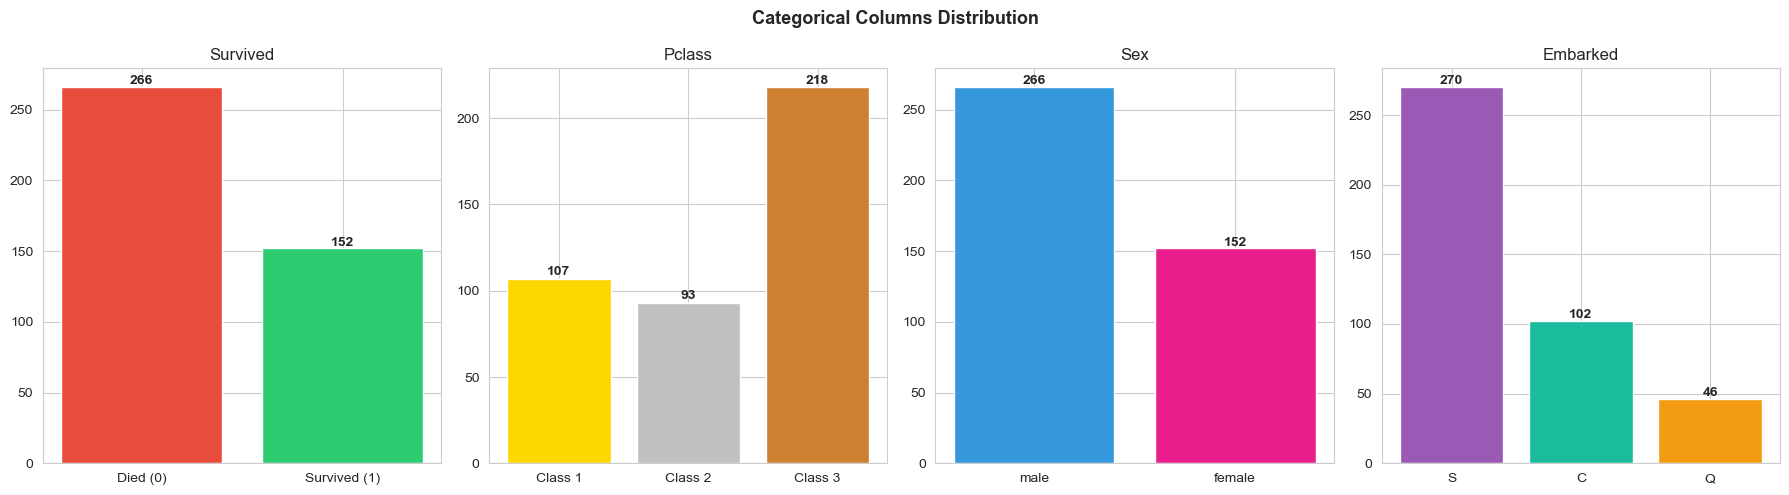

In [14]:
# Cell 14 - Categorical Charts
# نمودارهای توصیفی ستون های کیفی

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Categorical Columns Distribution', fontsize=13, fontweight='bold')

# Survived
vc = df_clean['Survived'].value_counts().sort_index()
axes[0].bar(['Died (0)', 'Survived (1)'], vc.values, color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0].set_title('Survived')
for i, v in enumerate(vc.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

# Pclass
vc = df_clean['Pclass'].value_counts().sort_index()
axes[1].bar(['Class 1','Class 2','Class 3'], vc.values, color=['gold','silver','#cd7f32'], edgecolor='white')
axes[1].set_title('Pclass')
for i, v in enumerate(vc.values):
    axes[1].text(i, v+2, str(v), ha='center', fontweight='bold')

# Sex
vc = df_clean['Sex'].value_counts()
axes[2].bar(vc.index, vc.values, color=['#3498db','#e91e8c'], edgecolor='white')
axes[2].set_title('Sex')
for i, v in enumerate(vc.values):
    axes[2].text(i, v+2, str(v), ha='center', fontweight='bold')

# Embarked
vc = df_clean['Embarked'].value_counts()
axes[3].bar(vc.index, vc.values, color=['#9b59b6','#1abc9c','#f39c12'], edgecolor='white')
axes[3].set_title('Embarked')
for i, v in enumerate(vc.values):
    axes[3].text(i, v+2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

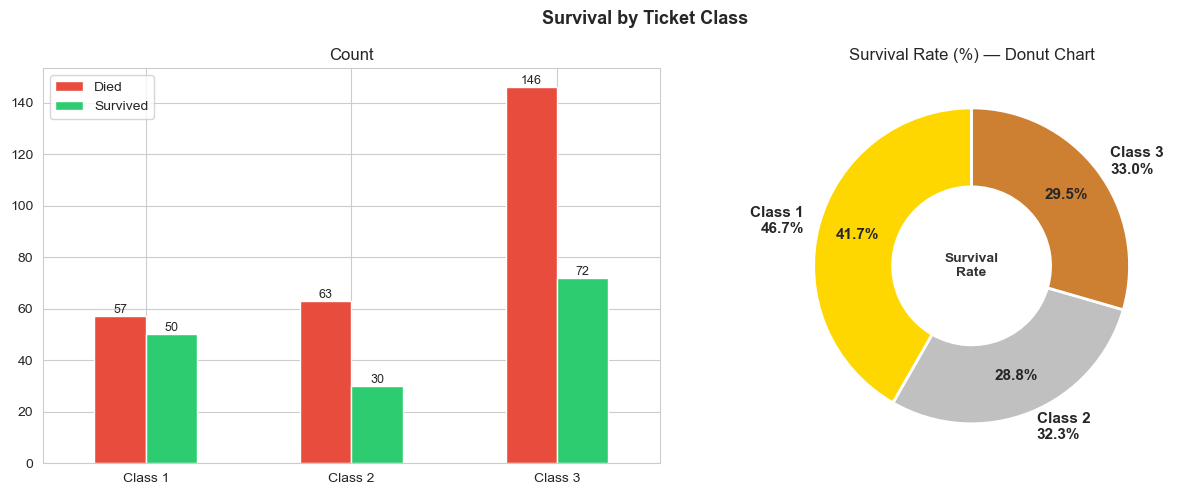

In [15]:
# Cell 15 - Survival by Pclass (Donut Chart)
# نرخ بقا بر اساس کلاس بلیت - نمودار دوناتی

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Survival by Ticket Class', fontsize=13, fontweight='bold')

ct = pd.crosstab(df_clean['Pclass'], df_clean['Survived'])
ct.columns = ['Died', 'Survived']
ct.index = ['Class 1', 'Class 2', 'Class 3']
ct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0].set_title('Count')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

rate = df_clean.groupby('Pclass')['Survived'].mean() * 100
labels = [f"Class {cls}\n{val:.1f}%" for cls, val in rate.items()]
wedges, texts, autotexts = axes[1].pie(
    rate.values, labels=labels,
    colors=['gold', 'silver', '#cd7f32'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2, width=0.5),
    textprops=dict(fontsize=11, fontweight='bold'), pctdistance=0.75)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].text(0, 0, 'Survival\nRate', ha='center', va='center',
             fontsize=10, fontweight='bold', color='#333')
axes[1].set_title('Survival Rate (%) — Donut Chart')

plt.tight_layout()
plt.show()


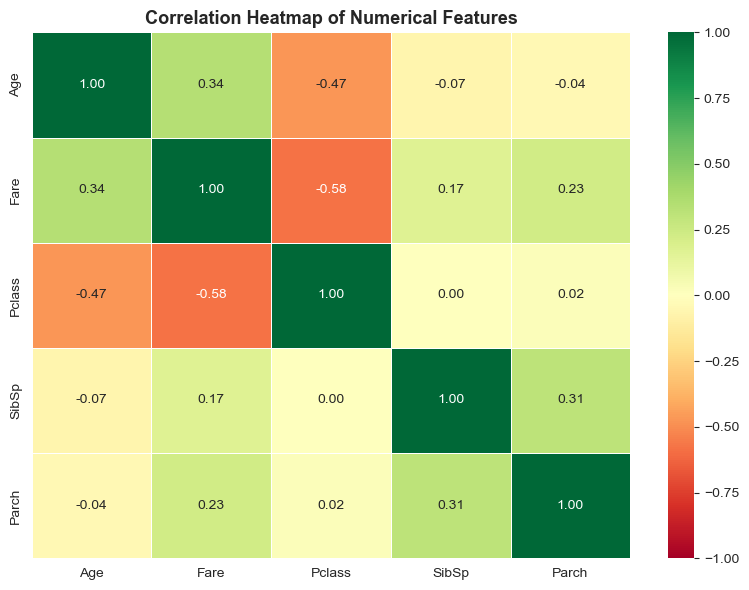

In [16]:
# Cell 16 - Correlation Heatmap
# همبستگی ویژگی‌های عددی

cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
corr = df_clean[cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

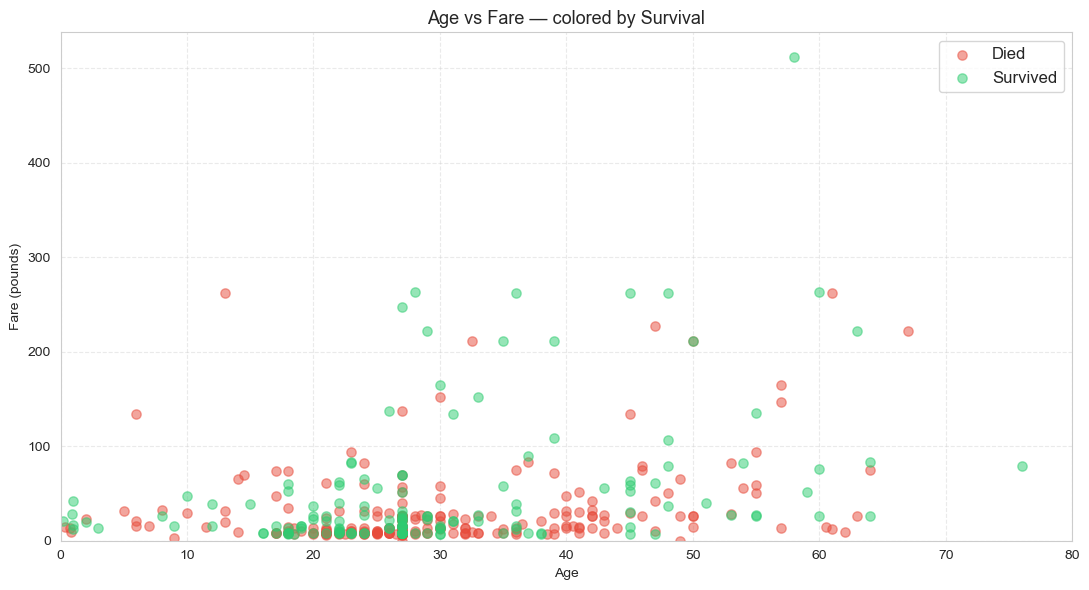

In [17]:
# Cell 17 - Scatter Plot: Age vs Fare
# نمودار پراکندگی سن در برابر قیمت بلیت

plt.figure(figsize=(11, 6))
for status, color, label in [(0,'#e74c3c','Died'), (1,'#2ecc71','Survived')]:
    sub = df_clean[df_clean['Survived'] == status]
    plt.scatter(sub['Age'], sub['Fare'], alpha=0.5, c=color, label=label, s=45)

plt.title('Age vs Fare — colored by Survival', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Fare (pounds)')
plt.xlim(0, 80)
plt.ylim(0, df_clean['Fare'].max() * 1.05)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


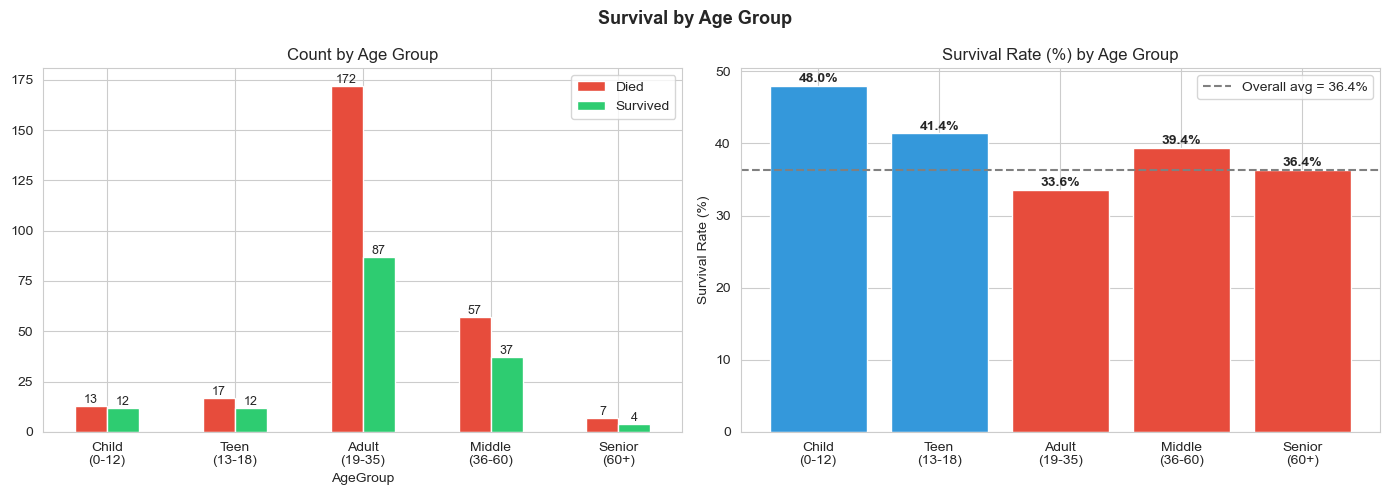

In [18]:
# Cell 18- Survival Rate by Age Group
# نرخ بقا بر اساس گروه سنی

df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child\n(0-12)', 'Teen\n(13-18)', 'Adult\n(19-35)', 'Middle\n(36-60)', 'Senior\n(60+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival by Age Group', fontsize=13, fontweight='bold')

ct = pd.crosstab(df_clean['AgeGroup'], df_clean['Survived'])
ct.columns = ['Died', 'Survived']
ct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0].set_title('Count by Age Group')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

rate = df_clean.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
colors_bar = ['#3498db' if v >= 40 else '#e74c3c' for v in rate.values]
bars = axes[1].bar(rate.index, rate.values, color=colors_bar, edgecolor='white')
axes[1].set_title('Survival Rate (%) by Age Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(df_clean['Survived'].mean()*100, color='gray', linestyle='--',
                linewidth=1.5, label=f'Overall avg = {df_clean["Survived"].mean()*100:.1f}%')
axes[1].legend()
for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


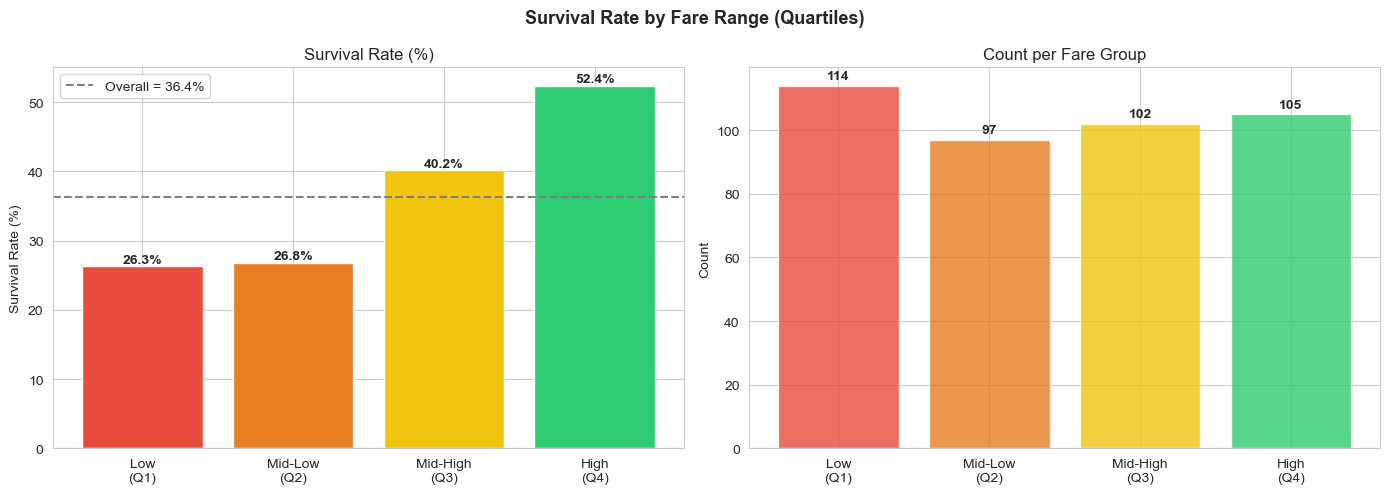

In [19]:
# Cell 19 - Survival by Fare Range
# نرخ بقا بر اساس بازه قیمت بلیت

df_clean['FareGroup'] = pd.qcut(df_clean['Fare'], q=4,
    labels=['Low\n(Q1)', 'Mid-Low\n(Q2)', 'Mid-High\n(Q3)', 'High\n(Q4)'])

rate = df_clean.groupby('FareGroup', observed=True)['Survived'].mean() * 100
count = df_clean.groupby('FareGroup', observed=True)['Survived'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival Rate by Fare Range (Quartiles)', fontsize=13, fontweight='bold')

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = axes[0].bar(rate.index, rate.values, color=colors, edgecolor='white')
axes[0].set_title('Survival Rate (%)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].axhline(df_clean['Survived'].mean()*100, color='gray', linestyle='--',
                linewidth=1.5, label=f'Overall = {df_clean["Survived"].mean()*100:.1f}%')
axes[0].legend()
for bar, val in zip(bars, rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
                 ha='center', fontweight='bold')

axes[1].bar(count.index, count.values, color=colors, edgecolor='white', alpha=0.8)
axes[1].set_title('Count per Fare Group')
axes[1].set_ylabel('Count')
for i, v in enumerate(count.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Accuracy : 0.6190476190476191
Precision: 0.6666666666666666
Recall   : 0.11764705882352941
F1 Score : 0.2

Confusion Matrix:
[[48  2]
 [30  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.96      0.75        50
           1       0.67      0.12      0.20        34

    accuracy                           0.62        84
   macro avg       0.64      0.54      0.47        84
weighted avg       0.64      0.62      0.53        84

LOGISTIC REGRESSION - MODEL COEFFICIENTS
Feature       Coefficient   Odds Ratio
--------------------------------------
Age               -0.0277       0.9726  ↓
Fare              +0.2758       1.3175  ↑
Pclass            -0.1475       0.8629  ↓
SibSp             +0.0936       1.0981  ↑
Parch             +0.1383       1.1483  ↑
Intercept         -0.6316

MODEL EVALUATION
  Accuracy : 0.6190  (61.90%)
  ROC-AUC  : 0.6394

Classification Report:
              precision    recall  f1-score   support

   

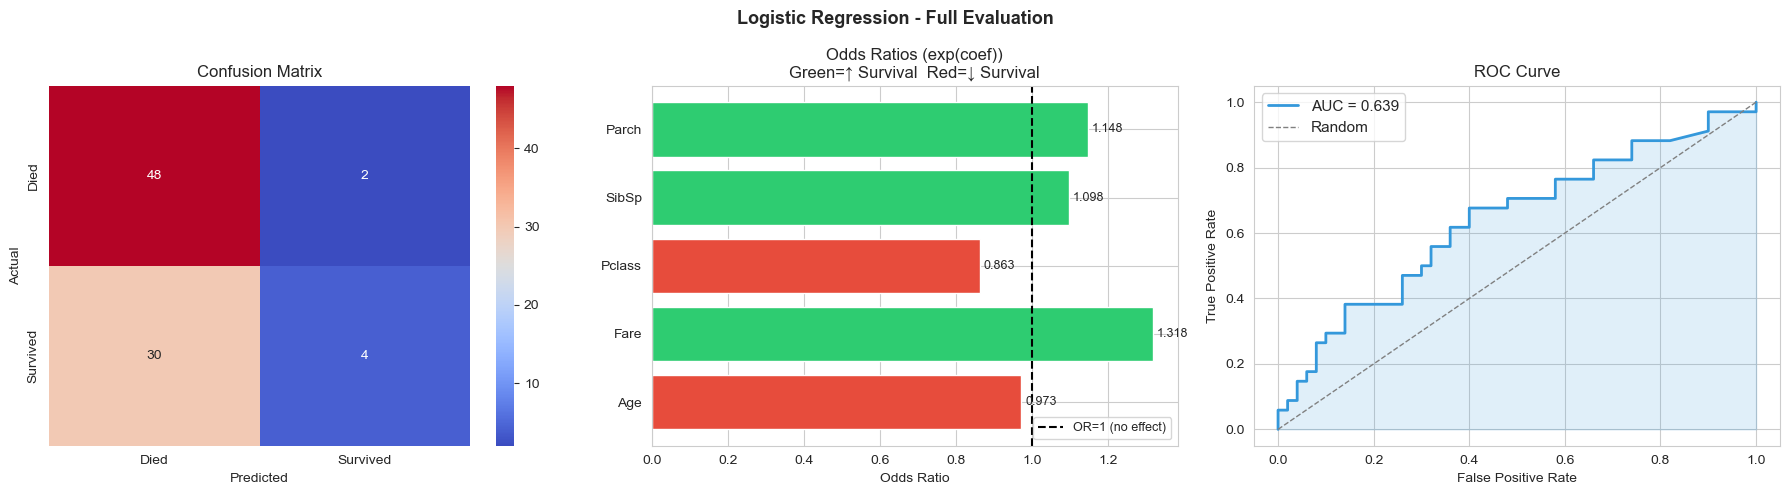

In [20]:
# Cell 20 - Logistic Regression Model (Enhanced Statistical Output)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve)
from sklearn.preprocessing import StandardScaler
import numpy as np

# آماده‌سازی داده
features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
X = df_clean[features]
y = df_clean['Survived']

# مقیاس‌بندی داده‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تقسیم داده به train و test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# ساخت و آموزش مدل
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# پیش‌بینی
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# پیش بینی
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# ===== ضرایب مدل =====
print('=' * 55)
print('LOGISTIC REGRESSION - MODEL COEFFICIENTS')
print('=' * 55)
print(f"{'Feature':<12} {'Coefficient':>12} {'Odds Ratio':>12}")
print('-' * 38)
for feat, coef in zip(features, model.coef_[0]):
    odds = np.exp(coef)
    direction = '↑' if coef > 0 else '↓'
    print(f"{feat:<12} {coef:>+12.4f} {odds:>12.4f}  {direction}")
print(f"{'Intercept':<12} {model.intercept_[0]:>+12.4f}")
print()

# ===== نتایج ارزیابی =====
acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
rep  = classification_report(y_test, y_pred,
                              target_names=['Died', 'Survived'])

print('=' * 55)
print('MODEL EVALUATION')
print('=' * 55)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ROC-AUC  : {auc:.4f}')
print()
print('Classification Report:')
print(rep)

# ===== نمودارها =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Logistic Regression - Full Evaluation', fontsize=13, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Coefficients (odds ratios)
odds_ratios = np.exp(model.coef_[0])
bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in model.coef_[0]]
axes[1].barh(features, odds_ratios, color=bar_colors, edgecolor='white')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='OR=1 (no effect)')
axes[1].set_title('Odds Ratios (exp(coef))\nGreen=↑ Survival  Red=↓ Survival')
axes[1].set_xlabel('Odds Ratio')
for i, v in enumerate(odds_ratios):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].legend(fontsize=9)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {auc:.3f}')
axes[2].plot([0,1],[0,1], '--', color='gray', linewidth=1, label='Random')
axes[2].fill_between(fpr, tpr, alpha=0.15, color='#3498db')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=11)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coef_df.sort_values('Coefficient', ascending=False))

plt.tight_layout()
plt.show()


In [21]:
# Cell 21 - Final Conclusion
# نتیجه گیری نهایی

s_female = df_clean[df_clean['Sex']=='female']['Survived'].mean() * 100
s_male   = df_clean[df_clean['Sex']=='male']['Survived'].mean() * 100
s_c1     = df_clean[df_clean['Pclass']==1]['Survived'].mean() * 100
s_c3     = df_clean[df_clean['Pclass']==3]['Survived'].mean() * 100
age_surv = df_clean[df_clean['Survived']==1]['Age'].mean()
age_dead = df_clean[df_clean['Survived']==0]['Age'].mean()

print('=' * 55)
print('FINAL CONCLUSION')
print('Goal: Did gender, class, and age affect survival?')
print('=' * 55)
print()
print('1. Gender (جنسیت):')
print(f'   Female: {s_female:.1f}%  |  Male: {s_male:.1f}%')
print('   => Women had much higher survival rate')
print()
print('2. Ticket Class (کلاس بلیت):')
print(f'   Class 1: {s_c1:.1f}%  |  Class 3: {s_c3:.1f}%')
print('   => Higher class = better access to lifeboats')
print()
print('3. Age (سن):')
print(f'   Survived mean age: {age_surv:.1f}')
print(f'   Died mean age:     {age_dead:.1f}')
print('   => Younger passengers had slightly better survival')
print()
print('ANSWER: Yes - gender and class were the most important')
print('factors in determining who survived the Titanic disaster.')
print('=' * 55)

FINAL CONCLUSION
Goal: Did gender, class, and age affect survival?

1. Gender (جنسیت):
   Female: 100.0%  |  Male: 0.0%
   => Women had much higher survival rate

2. Ticket Class (کلاس بلیت):
   Class 1: 46.7%  |  Class 3: 33.0%
   => Higher class = better access to lifeboats

3. Age (سن):
   Survived mean age: 29.7
   Died mean age:     29.5
   => Younger passengers had slightly better survival

ANSWER: Yes - gender and class were the most important
factors in determining who survived the Titanic disaster.
